In [1]:


from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/skin_split.rar" /content/

In [3]:
!ls /content

drive  sample_data  skin_split.rar


In [4]:
!apt-get install unrar
!unrar x /content/skin_split.rar /content/

Streaming output truncated to the last 5000 lines.
Extracting  /content/skin_split/train/nv/ISIC_0025194.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025198.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025200.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025201.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025202.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025203.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025204.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025205.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025206.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025207.jpg                 50%  OK 
Extracting  /content/skin_spl

In [5]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn

In [6]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import efficientnet
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input


In [7]:
from tensorflow.keras.regularizers import l2

In [8]:
# path for training and testing data
train_dir = "/content/skin_split/train"
test_dir = "/content/skin_split/test"

In [9]:
# data augmentation for training data
train_datagen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
   rotation_range=30,
   width_shift_range=0.1,
   height_shift_range=0.1,
   shear_range=0.1,
   zoom_range=0.2,
   horizontal_flip=True,
   fill_mode='nearest',
   validation_split=0.15
)

In [10]:
# generate data for training and validation data set
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 6813 images belonging to 7 classes.
Found 1197 images belonging to 7 classes.


In [11]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2005 images belonging to 7 classes.


In [12]:
#class weight as the HAM10000 is imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights using training labels
classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.384169884169884), 1: np.float64(2.780816326530612), 2: np.float64(1.3011841100076393), 3: np.float64(12.320072332730561), 4: np.float64(1.2857142857142858), 5: np.float64(0.21343984962406015), 6: np.float64(10.033873343151694)}


In [13]:
# model download and configuration
from tensorflow.keras.applications import *
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.applications import InceptionResNetV2

base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers :
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)

#x = BatchNormalization()(x)
#x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
#x = Dropout(0.3)(x)

x = Dense(7, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=x)


tl_model.summary()


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 54,738,151 (208.81 MB)

 Trainable params: 54,674,535 (208.57 MB)

 Non-trainable params: 63,616 (248.50 KB)

In [14]:
#optimizer
optimizer = Adam(0.0001)
tl_model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [15]:
# LearningRate; EarlyStopping; ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_efficent_skin_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [lr_reduce, early_stop, checkpoint]

In [16]:

#first training training or compiling
history = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights
)



Epoch 1/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2359 - loss: 2.5832
Epoch 1: val_accuracy improved from None to 0.57477, saving model to best_efficent_skin_model.keras

Epoch 1: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 484s 1s/step - accuracy: 0.3181 - loss: 2.2936 - val_accuracy: 0.5748 - val_loss: 2.3435 - learning_rate: 1.0000e-04
Epoch 2/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.5100 - loss: 1.5593
Epoch 2: val_accuracy improved from 0.57477 to 0.70844, saving model to best_efficent_skin_model.keras

Epoch 2: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 209s 982ms/step - accuracy: 0.5529 - loss: 1.5027 - val_accuracy: 0.7084 - val_loss: 1.1759 - learning_rate: 1.0000e-04
Epoch 3/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.6034 - loss: 1.2566
Epoch 3: val_accuracy improved from 0.70844 to 0.72431, saving model to best_efficent_skin_model.keras

Epoch

In [18]:
# to load the best model instead of starting from the last
tl_model.load_weights("best_efficent_skin_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 52 variables whereas the saved optimizer has 990 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [19]:

# freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# unfreeze top layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

tl_model.compile(
 optimizer=Adam(1e-5),
 loss='categorical_crossentropy',
 metrics=['accuracy']
)

fine_tune_history = tl_model.fit(
 train_generator,
 validation_data=val_generator,
 epochs=10,
 callbacks=callbacks,
 class_weight=class_weights
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.6704 - loss: 1.0783
Epoch 1: val_accuracy improved from 0.72431 to 0.72598, saving model to best_efficent_skin_model.keras

Epoch 1: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 233s 920ms/step - accuracy: 0.6706 - loss: 1.0757 - val_accuracy: 0.7260 - val_loss: 1.1104 - learning_rate: 1.0000e-05
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.6926 - loss: 1.0507
Epoch 2: val_accuracy improved from 0.72598 to 0.75272, saving model to best_efficent_skin_model.keras

Epoch 2: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 159s 744ms/step - accuracy: 0.6963 - loss: 1.0225 - val_accuracy: 0.7527 - val_loss: 1.0696 - learning_rate: 1.0000e-05
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.7161 - loss: 1.0313
Epoch 3: val_accuracy improved from 0.75272 to 0.76274, saving model to best_efficent_skin_model.ker

In [20]:
df=pd.DataFrame(tl_model.history.history)
df.to_csv('hist.csv')

<Axes: >

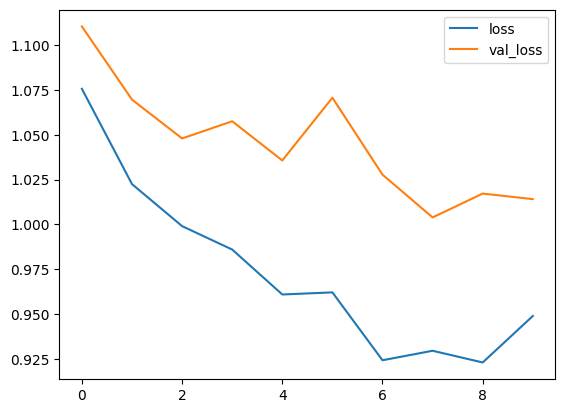

In [21]:
metrics = pd.DataFrame(tl_model.history.history)
metrics[["loss","val_loss"]].plot()

<Axes: >

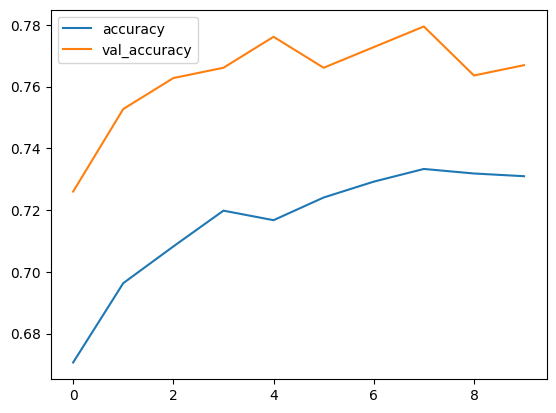

In [22]:
metrics[["accuracy","val_accuracy"]].plot()

In [23]:
tl_model.evaluate(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 463ms/step - accuracy: 0.7157 - loss: 1.1499


[1.1498823165893555, 0.7157106995582581]

In [24]:
predictions = tl_model.predict(test_generator, verbose=1)
predictions = predictions.argmax(axis=1)

test_labels = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 457ms/step


In [25]:
import sklearn
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(test_labels, predictions)

Normalized confusion matrix


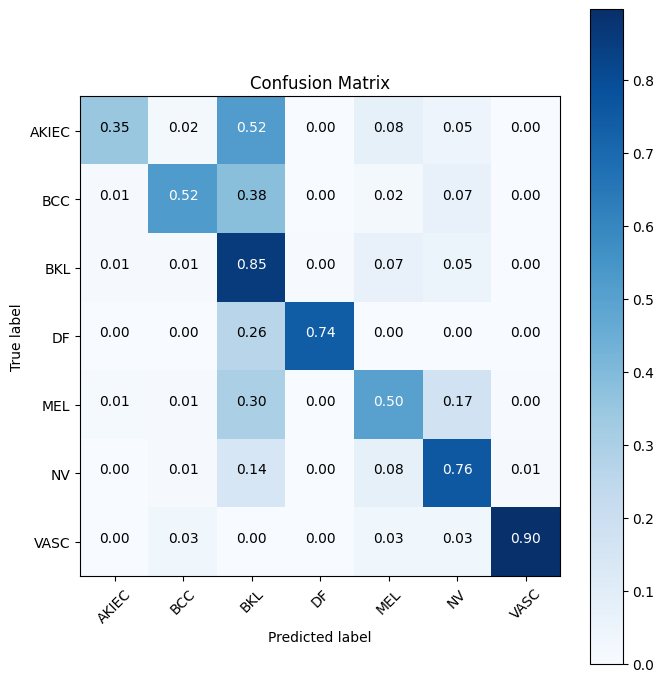

In [26]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        print(cm)

    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cm_plot_labels =['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)


In [27]:
!pip install disarray
import disarray

# Instantiate the confusion matrix DataFrame with index and columns
#cm = confusion_matrix(a,b)
df = pd.DataFrame(cm, index= ['AKIEC','BCC','BKL','DF','MEL','NV','VASC'], columns=['AKIEC','BCC','BKL','DF','MEL','NV','VASC'])
df.da.export_metrics()

,AKIEC,BCC,BKL,DF,MEL,NV,VASC,micro-average
accuracy,0.974564,0.967082,0.814464,0.995012,0.881297,0.806983,0.992020,0.918774
f1,0.474227,0.620690,0.502674,0.772727,0.482609,0.840017,0.764706,0.715711
false_discovery_rate,0.258065,0.239437,0.643939,0.190476,0.531646,0.057514,0.333333,0.284289
false_negative_rate,0.651515,0.475728,0.145455,0.260870,0.502242,0.242356,0.103448,0.284289
false_positive_rate,0.004126,0.008938,0.190476,0.002018,0.070707,0.093373,0.006579,0.047382
negative_predictive_value,0.978217,0.974664,0.978334,0.996976,0.936652,0.649407,0.998474,0.952618
positive_predictive_value,0.741935,0.760563,0.356061,0.809524,0.468354,0.942486,0.666667,0.715711
precision,0.741935,0.760563,0.356061,0.809524,0.468354,0.942486,0.666667,0.715711
recall,0.348485,0.524272,0.854545,0.739130,0.497758,0.757644,0.896552,0.715711
sensitivity,0.348485,0.524272,0.854545,0.739130,0.497758,0.757644,0.896552,0.715711


In [28]:
#downloading the best model
!zip skin_model.zip best_efficent_skin_model.keras
!ls
from google.colab import files
files.download("skin_model.zip")

  adding: best_efficent_skin_model.keras (deflated 8%)
best_efficent_skin_model.keras	hist.csv     skin_model.zip  skin_split.rar
drive				sample_data  skin_split


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>